In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import glob
import re
import os.path as op
from typing import Tuple, Iterator
# EEG utilities
import mne
# BIDS utilities
from util.io.bids import DataSink
from bids import BIDSLayout
# PLV functions
from util.io.ffr import read_epochs
# from util.io.plv import *
from scipy.stats import shapiro, mannwhitneyu
from arch.bootstrap import IIDBootstrap

In [207]:
# Functions for computing effects sizes for mann-whitney U
def Z_from_U(n1, n2, U):
    mean_U = n1 * n2 / 2
    sd_U = np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
    
    z = (U - mean_U) / sd_U
    return z

def cohens_r(n1, n2, z):
    N = n1 + n2
    r = z / np.sqrt(N)
    return r

### Load data

In [208]:
# fpaths = glob.glob('../data/bids/derivatives/plv/sub-*/*.csv')

# plvs = pd.DataFrame()
# for fpath in fpaths:
#     plvs = pd.concat([plvs, pd.read_csv(fpath, index_col = False)], ignore_index = True)

In [209]:
# # Regenerate null, but in a dataframe
# np.random.seed(42)
# draws = 1000
# subs = 1000
# null = np.array([])

# for i in range(subs):
#     plvs = list()
#     for j in range(draws):
#         # Draw random phases from a uniform distribution
#         phases = np.random.uniform(low = 0, high = 2*np.pi, size = 400)
#         plv = np.abs(np.mean(np.exp(1j * phases)))
#         plvs.append(plv)
#     mean_plv = np.mean(plvs)
#     null = np.append(null, mean_plv)


# # Get 95% CI
# CI90 = np.percentile(null, 90)
# print(f'90% CI: {CI90}')
# CI95 = np.percentile(null, 95)
# print(f'95% CI: {CI95}')

# # Create null dataframe
# null = pd.DataFrame({
#     'subj': 'null',
#     'accuracy_group': 'null',
#     'plv': null,
#     'stim_freq': 'null'
# })

90% CI: 0.04526546386691893
95% CI: 0.045550714538532794


In [210]:
# fpaths = glob.glob('../data/bids/derivatives/plv/sub-*/*.csv')
# plvs = pd.DataFrame()
# for fpath in fpaths:
#     plvs = pd.concat([plvs, pd.read_csv(fpath, index_col = False)], ignore_index = True)

In [211]:
# # Add accuracy group to dataframe
# accuracy = pd.read_csv('accuracy.csv', index_col = 0)
# accuracy = accuracy.rename(columns = {'subject': 'subj', 'score_group': 'accuracy_group'})
# plvs = plvs.rename(columns = {'sub': 'subj'})
# plvs = plvs.merge(accuracy, left_on = ["subj"], right_on = ["subj"])
# plvs.to_csv('plvs-accuracy.csv', index = False)
# plvs

,subj,stim_freq,draw,plv,accuracy,accuracy_group
0,7,130,1,0.030975,0.915718,low
1,7,130,2,0.033188,0.915718,low
2,7,130,3,0.013108,0.915718,low
3,7,130,4,0.057135,0.915718,low
4,7,130,5,0.074935,0.915718,low
...,...,...,...,...,...,...
125995,35,280,996,0.059334,0.980110,high
125996,35,280,997,0.113223,0.980110,high
125997,35,280,998,0.013293,0.980110,high
125998,35,280,999,0.049950,0.980110,high


In [212]:
palette_tab10 = sns.color_palette("tab10", 10)

In [258]:
pd.read_csv('plvs-accuracy.csv')

,subj,stim_freq,draw,plv,accuracy,accuracy_group
0,7,130,1,0.030975,0.915718,low
1,7,130,2,0.033188,0.915718,low
2,7,130,3,0.013108,0.915718,low
3,7,130,4,0.057135,0.915718,low
4,7,130,5,0.074935,0.915718,low
...,...,...,...,...,...,...
125995,35,280,996,0.059334,0.980110,high
125996,35,280,997,0.113223,0.980110,high
125997,35,280,998,0.013293,0.980110,high
125998,35,280,999,0.049950,0.980110,high


### 130 Hz

In [213]:
plvs_130 = plvs[plvs.stim_freq == 130]
plvs_130 = plvs_130.groupby(['subj', 'accuracy_group'], as_index=False)['plv'].mean()
plvs_130 = pd.concat([plvs_130, null])

cis = {}
bs = IIDBootstrap(plvs_130[plvs_130.accuracy_group == 'null'].plv)
ci = bs.conf_int(np.median, reps=10000, method='bca')
cis['null'] = ci.tolist()
print("null BCa 95% CI:", ci[0], ci[1])
bs = IIDBootstrap(plvs_130[plvs_130.accuracy_group == 'low'].plv)
ci = bs.conf_int(np.median, reps=10000, method='bca')
cis['low'] = ci.tolist()
print("low BCa 95% CI:", ci[0], ci[1])
bs = IIDBootstrap(plvs_130[plvs_130.accuracy_group == 'high'].plv)
ci = bs.conf_int(np.median, reps=10000, method='bca')
cis['high'] = ci.tolist()
print("high BCa 95% CI:", ci[0], ci[1])

descriptives = plvs_130.groupby(['accuracy_group'], as_index=False)['plv'].median()
descriptives = descriptives.rename(columns = {'plv': 'med'})
descriptives['Q1'] = plvs_130.groupby(['accuracy_group'], as_index=False)['plv'].quantile(0.25).plv
descriptives['Q3'] = plvs_130.groupby(['accuracy_group'], as_index=False)['plv'].quantile(0.75).plv
descriptives['IQR'] = descriptives.Q3 - descriptives.Q1
print(descriptives)

print(np.sum(plvs_130.plv[plvs_130.accuracy_group == 'null'] > descriptives.med[descriptives.accuracy_group == 'low'].tolist()[0]))
print(np.sum(plvs_130.plv[plvs_130.accuracy_group == 'null'] > descriptives.med[descriptives.accuracy_group == 'high'].tolist()[0]))

null BCa 95% CI: [0.04420701] [0.04433259]
low BCa 95% CI: [0.04464784] [0.04823136]
high BCa 95% CI: [0.04602568] [0.05045459]
  accuracy_group       med        Q1        Q3       IQR
0           high  0.048555  0.045816  0.051226  0.005410
1            low  0.045933  0.044663  0.049842  0.005179
2           null  0.044272  0.043786  0.044775  0.000989
14
0


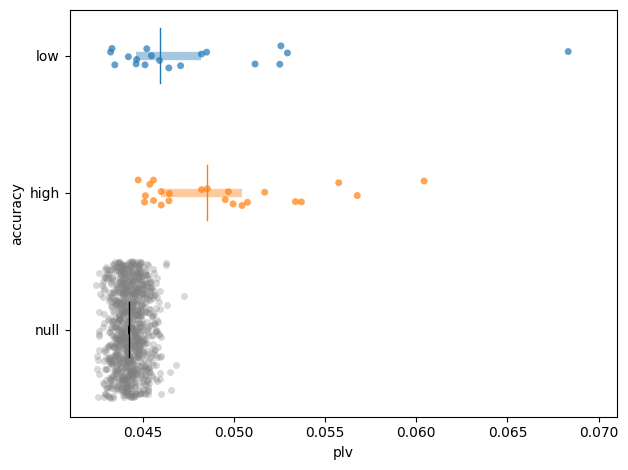

In [214]:
# Plot 
plvs_130 = plvs[plvs.stim_freq == 130]
plvs_130 = plvs_130.groupby(['subj', 'accuracy_group'], as_index=False)['plv'].mean()
plvs_130 = pd.concat([plvs_130, null])

sns.stripplot(
    data=plvs_130[plvs_130.accuracy_group!="null"],
    x="plv", y="accuracy_group", hue="accuracy_group",
    palette={"low": palette_tab10[0], "high": palette_tab10[1]},
    jitter=0.1, alpha = 0.7
)
sns.stripplot(
    data=plvs_130[plvs_130.accuracy_group=="null"],
    x="plv", y="accuracy_group",
    jitter=0.5, color="gray", alpha = 0.3
)

colors = [palette_tab10[0], palette_tab10[1], 'black']
med = plvs_130.loc[plvs_130["accuracy_group"] == 'low', "plv"].median()
plt.plot([med, med], [0-0.2, 0+0.2], color=colors[0], lw=1)
plt.hlines(0, cis['low'][0], cis['low'][1], color=colors[0], linewidth=6, alpha = 0.4)

med = plvs_130.loc[plvs_130["accuracy_group"] == 'high', "plv"].median()
plt.plot([med, med], [1-0.2, 1+0.2], color=colors[1], lw=1)
plt.hlines(1, cis['high'][0], cis['high'][1], color=colors[1], linewidth=6, alpha = 0.4)

med = plvs_130.loc[plvs_130["accuracy_group"] == 'null', "plv"].median()
plt.plot([med, med], [2-0.2, 2+0.2], color=colors[2], lw=1, zorder = 10)
plt.hlines(2, cis['null'][0], cis['null'][1], color=colors[2], linewidth=6, alpha = 1, zorder = 11)

plt.xlim(0.041, 0.071)
plt.ylabel("accuracy")
plt.tight_layout()
plt.savefig("../figs/PLV-130-hz-scatter.png", dpi = 300)

**Tests**

In [215]:
high = plvs_130[plvs_130.accuracy_group == 'high']
low = plvs_130[plvs_130.accuracy_group == 'low']
null = plvs_130[plvs_130.accuracy_group == 'null']

print('test for normality')
print(shapiro(high.plv))
print(shapiro(low.plv))
print(shapiro(null.plv))

print('compare groups')
u, p = mannwhitneyu(high.plv, null.plv, alternative = 'greater')
z = Z_from_U(len(high.plv), len(null.plv), u)
r = cohens_r(len(high.plv), len(null.plv), z)
print(f'high vs null: u = {u}, p = {p}, r = {r}')
pu, p = mannwhitneyu(low.plv, null.plv, alternative = 'greater')
z = Z_from_U(len(low.plv), len(null.plv), u)
r = cohens_r(len(low.plv), len(null.plv), z)
print(f'low vs null: u = {u}, p = {p}, r = {r}')
u, p = mannwhitneyu(high.plv, low.plv, alternative = 'greater')
z = Z_from_U(len(high.plv), len(low.plv), u)
r = cohens_r(len(high.plv), len(low.plv), z)
print(f'high vs low: u = {u}, p = {p}, r = {r}')

test for normality
ShapiroResult(statistic=0.8883525133132935, pvalue=0.014656975865364075)
ShapiroResult(statistic=0.7237424254417419, pvalue=0.00010814608685905114)
ShapiroResult(statistic=0.9964521527290344, pvalue=0.023049497976899147)
compare groups
high vs null: u = 22300.0, p = 6.355970069162389e-15, r = 0.24102531844408437
low vs null: u = 22300.0, p = 1.223166267838532e-05, r = 0.31552706253508644
high vs low: u = 289.0, p = 0.03845173520934555, r = 0.2749034236223175


### 200 Hz

In [236]:
plvs_200 = plvs[plvs.stim_freq == 200]
plvs_200 = plvs_200.groupby(['subj', 'accuracy_group'], as_index=False)['plv'].mean()
plvs_200 = pd.concat([plvs_200, null])
cis = {}
bs = IIDBootstrap(plvs_200[plvs_200.accuracy_group == 'null'].plv)
ci = bs.conf_int(np.median, reps=10000, method='bca')
cis['null'] = ci.tolist()
print("null BCa 95% CI:", ci[0], ci[1])
bs = IIDBootstrap(plvs_200[plvs_200.accuracy_group == 'low'].plv)
ci = bs.conf_int(np.median, reps=10000, method='bca')
cis['low'] = ci.tolist()
print("low BCa 95% CI:", ci[0], ci[1])
bs = IIDBootstrap(plvs_200[plvs_200.accuracy_group == 'high'].plv)
ci = bs.conf_int(np.median, reps=10000, method='bca')
cis['high'] = ci.tolist()
print("high BCa 95% CI:", ci[0], ci[1])

descriptives = plvs_200.groupby(['accuracy_group'], as_index=False)['plv'].median()
descriptives = descriptives.rename(columns = {'plv': 'med'})
descriptives['Q1'] = plvs_200.groupby(['accuracy_group'], as_index=False)['plv'].quantile(0.25).plv
descriptives['Q3'] = plvs_200.groupby(['accuracy_group'], as_index=False)['plv'].quantile(0.75).plv
descriptives['IQR'] = descriptives.Q3 - descriptives.Q1
print(descriptives)

print(np.sum(plvs_200.plv[plvs_200.accuracy_group == 'null'] > descriptives.med[descriptives.accuracy_group == 'low'].tolist()[0]))
print(np.sum(plvs_200.plv[plvs_200.accuracy_group == 'null'] > descriptives.med[descriptives.accuracy_group == 'high'].tolist()[0]))

null BCa 95% CI: [0.04420647] [0.04433259]
low BCa 95% CI: [0.0444599] [0.0524093]
high BCa 95% CI: [0.04476984] [0.05671206]
  accuracy_group       med        Q1        Q3       IQR
0           high  0.049542  0.044664  0.057260  0.012597
1            low  0.047590  0.044870  0.055964  0.011094
2           null  0.044272  0.043786  0.044775  0.000989
0
0


In [249]:
np.histogram(null.plv)

(array([ 29,  93, 186, 250, 227, 132,  63,  14,   4,   2]),
 array([0.04246075, 0.04294065, 0.04342056, 0.04390046, 0.04438036,
        0.04486027, 0.04534017, 0.04582007, 0.04629998, 0.04677988,
        0.04725978]))

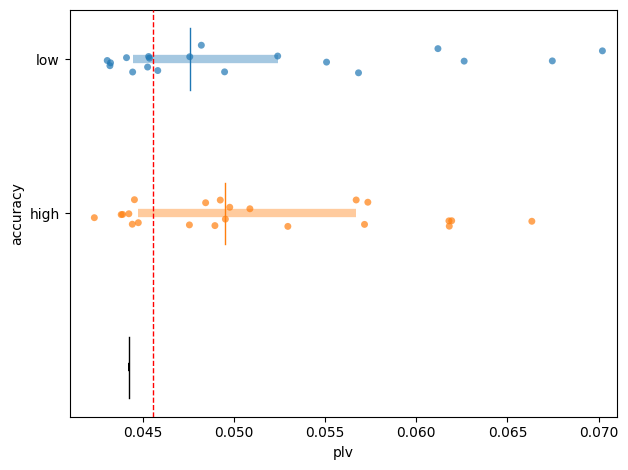

In [255]:
# Plot 
plvs_200 = plvs[plvs.stim_freq == 200]
plvs_200 = plvs_200.groupby(['subj', 'accuracy_group'], as_index=False)['plv'].mean()
plvs_200 = pd.concat([plvs_200, null])

sns.stripplot(
    data=plvs_200[plvs_200.accuracy_group!="null"],
    x="plv", y="accuracy_group", hue="accuracy_group",
    palette={"low": palette_tab10[0], "high": palette_tab10[1]},
    jitter=0.1, alpha = 0.7
)

# sns.histplot(
#     data=plvs_200[plvs_200.accuracy_group=="null"],
#     x="plv", color = 'gray', alpha = 0.4
# )
counts, bins = np.histogram(null.plv, bins=20)
counts = counts / counts.max() * (null.plv.max() * 0.05)  # make short histogram

for c, left, right in zip(counts, bins[:-1], bins[1:]):
    ax.barh(null.plv.min()*0.95, width=right-left, height=c,
            left=left, color='gray', alpha=0.3)

colors = [palette_tab10[0], palette_tab10[1], 'black']
med = plvs_200.loc[plvs_200["accuracy_group"] == 'low', "plv"].median()
plt.plot([med, med], [0-0.2, 0+0.2], color=colors[0], lw=1)
plt.hlines(0, cis['low'][0], cis['low'][1], color=colors[0], linewidth=6, alpha = 0.4)

med = plvs_200.loc[plvs_200["accuracy_group"] == 'high', "plv"].median()
plt.plot([med, med], [1-0.2, 1+0.2], color=colors[1], lw=1)
plt.hlines(1, cis['high'][0], cis['high'][1], color=colors[1], linewidth=6, alpha = 0.4)

med = plvs_200.loc[plvs_200["accuracy_group"] == 'null', "plv"].median()
plt.axvline(x = CI95, lw = 1, linestyle = '--', color = 'red', zorder = 9)
plt.plot([med, med], [2-0.2, 2+0.2], color=colors[2], lw=1, zorder = 10)
plt.hlines(2, cis['null'][0], cis['null'][1], color=colors[2], linewidth=6, alpha = 1, zorder = 11)

plt.xlim(0.041, 0.071)
plt.ylabel("accuracy")
plt.tight_layout()
plt.savefig("../figs/PLV-200-hz-scatter.png", dpi = 300)

**Tests**

In [218]:
high = plvs_200[plvs_200.accuracy_group == 'high']
low = plvs_200[plvs_200.accuracy_group == 'low']
null = plvs_200[plvs_200.accuracy_group == 'null']

print('test for normality')
print(shapiro(high.plv))
print(shapiro(low.plv))
print(shapiro(null.plv))

print('compare groups')
u, p = mannwhitneyu(high.plv, null.plv, alternative = 'greater')
z = Z_from_U(len(high.plv), len(null.plv), u)
r = cohens_r(len(high.plv), len(null.plv), z)
print(f'high vs null: u = {u}, p = {p}, r = {r}')
pu, p = mannwhitneyu(low.plv, null.plv, alternative = 'greater')
z = Z_from_U(len(low.plv), len(null.plv), u)
r = cohens_r(len(low.plv), len(null.plv), z)
print(f'low vs null: u = {u}, p = {p}, r = {r}')
u, p = mannwhitneyu(high.plv, low.plv, alternative = 'greater')
z = Z_from_U(len(high.plv), len(low.plv), u)
r = cohens_r(len(high.plv), len(low.plv), z)
print(f'high vs low: u = {u}, p = {p}, r = {r}')

test for normality
ShapiroResult(statistic=0.9000139832496643, pvalue=0.025296542793512344)
ShapiroResult(statistic=0.8375034332275391, pvalue=0.004228716250509024)
ShapiroResult(statistic=0.9964521527290344, pvalue=0.023049497976899147)
compare groups
high vs null: u = 19060.0, p = 3.407652669038444e-08, r = 0.16871772291085907
low vs null: u = 19060.0, p = 9.26691730660956e-06, r = 0.2356592748308927
high vs low: u = 243.0, p = 0.2720931928031376, r = 0.09553381388293304


### 280 Hz

In [219]:
plvs_280 = plvs[plvs.stim_freq == 280]
plvs_280 = plvs_280.groupby(['subj', 'accuracy_group'], as_index=False)['plv'].mean()
plvs_280 = pd.concat([plvs_280, null])
cis = {}
bs = IIDBootstrap(plvs_280[plvs_280.accuracy_group == 'null'].plv)
ci = bs.conf_int(np.median, reps=10000, method='bca')
cis['null'] = ci.tolist()
print("null BCa 95% CI:", ci[0], ci[1])
bs = IIDBootstrap(plvs_280[plvs_280.accuracy_group == 'low'].plv)
ci = bs.conf_int(np.median, reps=10000, method='bca')
cis['low'] = ci.tolist()
print("low BCa 95% CI:", ci[0], ci[1])
bs = IIDBootstrap(plvs_280[plvs_280.accuracy_group == 'high'].plv)
ci = bs.conf_int(np.median, reps=10000, method='bca')
cis['high'] = ci.tolist()
print("high BCa 95% CI:", ci[0], ci[1])

descriptives = plvs_280.groupby(['accuracy_group'], as_index=False)['plv'].median()
descriptives = descriptives.rename(columns = {'plv': 'med'})
descriptives['Q1'] = plvs_280.groupby(['accuracy_group'], as_index=False)['plv'].quantile(0.25).plv
descriptives['Q3'] = plvs_280.groupby(['accuracy_group'], as_index=False)['plv'].quantile(0.75).plv
descriptives['IQR'] = descriptives.Q3 - descriptives.Q1
print(descriptives)

print(np.sum(plvs_280.plv[plvs_280.accuracy_group == 'null'] > descriptives.med[descriptives.accuracy_group == 'low'].tolist()[0]))
print(np.sum(plvs_280.plv[plvs_280.accuracy_group == 'null'] > descriptives.med[descriptives.accuracy_group == 'high'].tolist()[0]))

null BCa 95% CI: [0.04420941] [0.04433108]
low BCa 95% CI: [0.04559498] [0.05430516]
high BCa 95% CI: [0.04541733] [0.04851041]
  accuracy_group       med        Q1        Q3       IQR
0           high  0.046706  0.045386  0.049600  0.004213
1            low  0.050819  0.045939  0.055743  0.009804
2           null  0.044272  0.043786  0.044775  0.000989
0
2


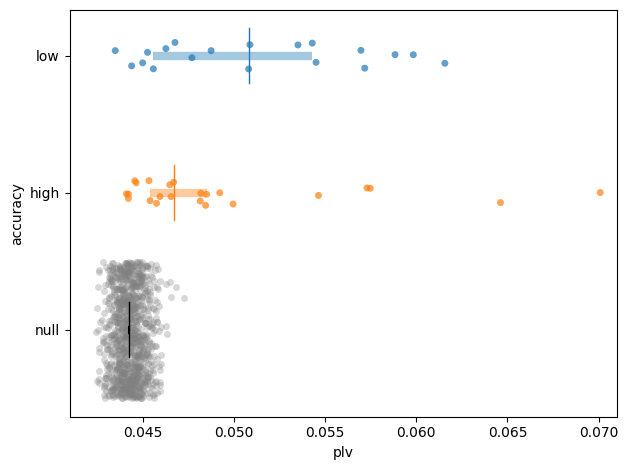

In [220]:
# Plot 
plvs_280 = plvs[plvs.stim_freq == 280]
plvs_280 = plvs_280.groupby(['subj', 'accuracy_group'], as_index=False)['plv'].mean()
plvs_280 = pd.concat([plvs_280, null])

sns.stripplot(
    data=plvs_280[plvs_280.accuracy_group!="null"],
    x="plv", y="accuracy_group", hue="accuracy_group",
    palette={"low": palette_tab10[0], "high": palette_tab10[1]},
    jitter=0.1, alpha = 0.7
)
sns.stripplot(
    data=plvs_280[plvs_280.accuracy_group=="null"],
    x="plv", y="accuracy_group",
    jitter=0.5, color="gray", alpha = 0.3
)

colors = [palette_tab10[0], palette_tab10[1], 'black']
med = plvs_280.loc[plvs_280["accuracy_group"] == 'low', "plv"].median()
plt.plot([med, med], [0-0.2, 0+0.2], color=colors[0], lw=1)
plt.hlines(0, cis['low'][0], cis['low'][1], color=colors[0], linewidth=6, alpha = 0.4)

med = plvs_280.loc[plvs_280["accuracy_group"] == 'high', "plv"].median()
plt.plot([med, med], [1-0.2, 1+0.2], color=colors[1], lw=1)
plt.hlines(1, cis['high'][0], cis['high'][1], color=colors[1], linewidth=6, alpha = 0.4)

med = plvs_280.loc[plvs_280["accuracy_group"] == 'null', "plv"].median()
plt.plot([med, med], [2-0.2, 2+0.2], color=colors[2], lw=1, zorder = 10)
plt.hlines(2, cis['null'][0], cis['null'][1], color=colors[2], linewidth=6, alpha = 1, zorder = 11)

plt.xlim(0.041, 0.071)
plt.ylabel("accuracy")
plt.tight_layout()
plt.savefig("../figs/PLV-280-hz-scatter.png", dpi = 300)

**Tests**

In [221]:
high = plvs_280[plvs_280.accuracy_group == 'high']
low = plvs_280[plvs_280.accuracy_group == 'low']
null = plvs_280[plvs_280.accuracy_group == 'null']

print('test for normality')
print(shapiro(high.plv))
print(shapiro(low.plv))
print(shapiro(null.plv))

print('compare groups')
u, p = mannwhitneyu(high.plv, null.plv, alternative = 'greater')
z = Z_from_U(len(high.plv), len(null.plv), u)
r = cohens_r(len(high.plv), len(null.plv), z)
print(f'high vs null: u = {u}, p = {p}, r = {r}')
pu, p = mannwhitneyu(low.plv, null.plv, alternative = 'greater')
z = Z_from_U(len(low.plv), len(null.plv), u)
r = cohens_r(len(low.plv), len(null.plv), z)
print(f'low vs null: u = {u}, p = {p}, r = {r}')
u, p = mannwhitneyu(high.plv, low.plv, alternative = 'greater')
z = Z_from_U(len(high.plv), len(low.plv), u)
r = cohens_r(len(high.plv), len(low.plv), z)
print(f'high vs low: u = {u}, p = {p}, r = {r}')

test for normality
ShapiroResult(statistic=0.7507975697517395, pvalue=6.893932004459202e-05)
ShapiroResult(statistic=0.9240527153015137, pvalue=0.13448750972747803)
ShapiroResult(statistic=0.9964521527290344, pvalue=0.023049497976899147)
compare groups
high vs null: u = 20529.0, p = 5.797347614210471e-11, r = 0.2015016296510776
low vs null: u = 20529.0, p = 2.511344104607818e-10, r = 0.27187093536714596
high vs low: u = 177.0, p = 0.8557380856128591, r = -0.16182258269966207
